# Synthetic Experiment

## Data Generation
Parameters:
 - $d$ the ambient dimension (int, $>1$)
 - $m$ the kernel size (int)
 - $K$ the width of the ground-true network (complexity)
 - $H=\{\pi_1,\cdots,\pi_L\}$ a set of rank $m$ projection $\mathbb{R}^d\rightarrow \mathbb{R}^m$ (diagonal matrix of entries in $\{0,1\}$) of size $L$ (a list of matrices).
 - $\sigma$ noise scale
 - $N$ the number of samples to generate

Output: clean dataset $\{(x_i,f(x_i))\}_{i=1}^N$ (for validation), noisy dataset $\{(x_i,y_i)\}_{i=1}^N$ (for training), where $f$ is a ground-true function defined by $H$ and some random matrix, and $y_i=f(x_i)+N(0,\sigma^2)$ (a regression problem). 

The ground-true function $f$ is of the form:
$$
f(x) = \sum_{k=1}^K v_k \frac{1}{L}\sum_{l\in H} ReLU (w_k^\top (\pi_l(x))-b_k) +\beta
$$
sparse connectivity + parameter sharing + global average pooling

----

1. def generate_local_view(d, m, L, random_seed), return list H
2. def ground_true_function(d,K, m, H, random seed), return a function from $\mathbb{R}^d$ to $\mathbb{R}$
3. def generate_dataset 

## Network Training 

Network articheture (with input $H$, width $K$) 
Model:
$$
f_{\theta}(x) = \sum_{k=1}^K v_k \frac{1}{L}\sum_{l\in H} ReLU (w_k^\top (\pi_l(x))-b_k) +\beta
$$
where $\theta=\{v_k, w_k,b_k,\beta\}_{k=1}^N$ are trainable parameters (using Kaiming initialization)

optimizer: vanilla GD, parameter (lr, weight-decay, batchsize (full-batch by default), gradient_clip (threshold), epochs)

Let $f_0$ be the ground-true function, $f$ be the predictor produced by the neural network training.
- train loss of $f$: $\frac{1}{n} \sum_{i=1}^n(f(x_i)-y_i)^2$ (use noisy data to train)
- train MSE of $f$: $\frac{1}{n} \sum_{i=1}^n(f(x_i)-f_0(x_i))^2$ (use clean data to test)

Print and collect the above metric during the training, and plot the training curve.


In [7]:
# Data Generation - Complete Implementation
import numpy as np  
from typing import Callable, Tuple

def generate_local_view(d: int, m: int, L: int, seed: int) -> np.ndarray:
    """
    Generate a set of local views (projection indices) for the synthetic experiment.
    
    Args:
        d: Ambient dimension of the input space
        m: Size of each local view (kernel size)
        L: Number of local views
        seed: Random seed for reproducibility
    
    Returns:
        H: Array of shape (L, m) where each row contains m sorted indices from {0,...,d-1}
    """
    rng = np.random.default_rng(seed)
    # Generate L different local views, each selecting m indices from d dimensions
    H = [np.sort(rng.choice(d, size=m, replace=False)) for _ in range(L)]
    return np.stack(H)


def ground_true_function_batch(d: int, K: int, H: np.ndarray, random_seed: int) -> Callable[[np.ndarray], np.ndarray]:
    """
    Create the ground truth function f(x) that generates clean labels.
    This version supports BATCH INPUT for faster computation.
    
    The function has the form:
    f(x) = sum_{k=1}^K v_k * (1/L) * sum_{l in H} ReLU(w_k^T * pi_l(x) - b_k) + beta
    
    Args:
        d: Ambient dimension
        K: Width of the network (number of hidden units)
        H: Local view indices, shape (L, m)
        random_seed: Random seed for parameter initialization
    
    Returns:
        f: A function that maps X (numpy array of shape (N, d) or (d,)) to outputs of shape (N,) or scalar
    """
    rng = np.random.default_rng(random_seed)
    m = H.shape[1]  # Dimension of each local view
    L = H.shape[0]  # Number of local views
    
    # Initialize parameters for the ground truth function
    v = rng.normal(0, 1, K)  # Output weights, shape (K,)
    w = rng.normal(0, 1, (K, m))         # Hidden layer weights, shape (K, m)
    b = rng.uniform(-0.5, 0.5, K)        # Biases, shape (K,)
    beta = rng.uniform(-1, 1)            # Global bias, scalar
    
    def f(X: np.ndarray) -> np.ndarray:
        """
        Evaluate the ground truth function at input X.
        
        Args:
            X: Input array of shape (N, d) for batch or (d,) for single sample
        
        Returns:
            Output array of shape (N,) for batch or scalar for single sample
        """
        # Handle both single sample and batch input
        is_single = (X.ndim == 1)
        if is_single:
            X = X[None, :]  # Convert (d,) to (1, d)
        
        # X now has shape (N, d)
        N = X.shape[0]
        
        # Extract local views: X_H has shape (N, L, m)
        # H has shape (L, m), we use advanced indexing
        X_H = X[:, H]  # Shape: (N, L, m)
        
        # Reshape for batch matrix multiplication
        # X_H_flat: (N * L, m)
        X_H_flat = X_H.reshape(N * L, m)
        
        # Apply linear transformation: (N * L, m) @ (m, K) -> (N * L, K)
        # Then subtract bias b of shape (K,) - broadcasting handles it
        hidden_flat = X_H_flat @ w.T - b  # Shape: (N * L, K)
        
        # Apply ReLU activation
        hidden_flat = np.maximum(0, hidden_flat)
        
        # Reshape back: (N, L, K)
        hidden = hidden_flat.reshape(N, L, K)
        
        # Global average pooling over L local views: (N, K)
        pooled = np.mean(hidden, axis=1)
        
        # Final output: weighted sum + global bias
        # (N, K) * (K,) -> (N,) via broadcasting and sum
        output = (pooled * v).sum(axis=1) + beta
        
        # Return scalar if input was single sample
        if is_single:
            return output[0]
        
        return output
    
    return f


def generate_dataset_fast(d: int, K: int, m: int, L: int, N: int, sigma: float, random_seed: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate synthetic dataset with clean and noisy labels.
    OPTIMIZED VERSION with batch processing.
    
    Args:
        d: Ambient dimension
        K: Width of ground truth network
        m: Size of each local view
        L: Number of local views
        N: Number of samples
        sigma: Noise standard deviation for labels
        random_seed: Random seed
    
    Returns:
        clean_dataset: Array of shape (N, d+1), where last column is f(x_i)
        noisy_dataset: Array of shape (N, d+1), where last column is y_i = f(x_i) + noise
        H: Local view indices, shape (L, m)
    """
    rng = np.random.default_rng(random_seed)
    
    # Generate local views (projection indices)
    H = generate_local_view(d, m, L, random_seed)
    
    # Create ground truth function (batch version)
    f = ground_true_function_batch(d, K, H, random_seed)
    
    # Generate normalized input samples: each x_i is sampled from normal distribution then normalized
    X = rng.normal(0, 1, (N, d))
    # Vectorized normalization - much faster!
    X = X / np.linalg.norm(X, axis=1, keepdims=True)
    
    # Generate clean labels: f(X) - BATCH PROCESSING, no loop!
    f_X = f(X)  # Shape: (N,)
    
    # Generate noisy labels: y_i = f(x_i) + N(0, sigma^2)
    noise = rng.normal(0, sigma, N)
    y = f_X + noise
    
    # Combine features and labels
    clean_dataset = np.concatenate([X, f_X[:, None]], axis=1)
    noisy_dataset = np.concatenate([X, y[:, None]], axis=1)
    
    return clean_dataset, noisy_dataset, H

In [8]:
# Neural Network Training - PyTorch Implementation
import torch
import torch.nn as nn
import torch.optim as optim
from typing import Dict, List
import matplotlib.pyplot as plt

class LocalViewNetwork(nn.Module):
    """
    Neural network that mimics the ground truth function structure.
    
    Architecture:
    f_theta(x) = sum_{k=1}^K v_k * (1/L) * sum_{l in H} ReLU(w_k^T * pi_l(x) - b_k) + beta
    
    This implements:
    - Sparse connectivity via local views H
    - Parameter sharing across local views
    - Global average pooling
    """
    
    def __init__(self, d: int, K: int, H: np.ndarray):
        """
        Initialize the network.
        
        Args:
            d: Input dimension
            K: Width (number of hidden units)
            H: Local view indices, numpy array of shape (L, m)
        """
        super(LocalViewNetwork, self).__init__()
        
        # Store hyperparameters
        self.d = d
        self.K = K
        self.L = H.shape[0]  # Number of local views
        self.m = H.shape[1]  # Size of each local view
        
        # Register H as a buffer (not a trainable parameter, but part of model state)
        self.register_buffer('H', torch.from_numpy(H).long())
        
        # Trainable parameters
        # w: weight matrix of shape (K, m) for local view processing
        self.w = nn.Parameter(torch.empty(K, self.m))
        # b: bias vector of shape (K,)
        self.b = nn.Parameter(torch.empty(K))
        # v: output weights of shape (K,)
        self.v = nn.Parameter(torch.empty(K))
        # beta: global bias (scalar)
        self.beta = nn.Parameter(torch.empty(1))
        
        # Initialize parameters using Kaiming initialization
        self._initialize_parameters()
    
    def _initialize_parameters(self):
        """Initialize parameters using Kaiming (He) initialization for ReLU networks."""
        # Kaiming initialization for w: std = sqrt(2 / fan_in)
        nn.init.kaiming_normal_(self.w, mode='fan_in', nonlinearity='relu')
        
        # Initialize biases to zero (common practice)
        nn.init.zeros_(self.b)
        
        # Initialize output weights with smaller values
        nn.init.normal_(self.v, mean=0, std=1/np.sqrt(self.K))
        
        # Initialize global bias
        nn.init.uniform_(self.beta, -0.1, 0.1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Optimized forward pass using einsum for better performance.
    
        Args:
            x: Input tensor of shape (batch_size, d)
    
        Returns:
            output: Predictions of shape (batch_size,)
        """
        batch_size = x.shape[0]
    
        # Extract local views: x_H has shape (batch_size, L, m)
        # H has shape (L, m), indexing gives us the local views
        x_H = x[:, self.H]  # Shape: (batch_size, L, m)
    
        # Apply linear transformation using einsum (more efficient)
        # x_H: (batch_size, L, m)
        # w: (K, m)
        # Result: (batch_size, L, K)
        hidden = torch.einsum('blm,km->blk', x_H, self.w) - self.b
    
         # Apply ReLU activation
        hidden = torch.relu(hidden)
    
        # Global average pooling over L local views: (batch_size, K)
        pooled = hidden.mean(dim=1)
    
        # Final output using einsum: (batch_size, K) * (K,) -> (batch_size,)
        output = torch.einsum('bk,k->b', pooled, self.v) + self.beta
        
        return output


def train_network(
    model: nn.Module,
    clean_dataset: np.ndarray,
    noisy_dataset: np.ndarray,
    lr: float = 0.01,
    weight_decay: float = 0.0,
    batch_size: int = None,
    gradient_clip: float = None,
    epochs: int = 1000,
    print_every: int = 100,
    device: str = 'cpu'
) -> Dict[str, List[float]]:
    """
    Train the neural network using vanilla gradient descent.
    
    Args:
        model: The neural network model
        clean_dataset: Clean data (X, f(X)) for computing true MSE, shape (N, d+1)
        noisy_dataset: Noisy data (X, y) for training, shape (N, d+1)
        lr: Learning rate
        weight_decay: L2 regularization coefficient
        batch_size: Batch size (None means full-batch)
        gradient_clip: Gradient clipping threshold (None means no clipping)
        epochs: Number of training epochs
        print_every: Print metrics every N epochs
        device: Device to train on ('cpu' or 'cuda')
    
    Returns:
        history: Dictionary containing training metrics over epochs
    """
    # Move model to device
    model = model.to(device)
    
    # Prepare datasets
    X_train = torch.FloatTensor(noisy_dataset[:, :-1]).to(device)  # Features
    y_train = torch.FloatTensor(noisy_dataset[:, -1]).to(device)   # Noisy labels
    
    X_clean = torch.FloatTensor(clean_dataset[:, :-1]).to(device)  # Features
    y_clean = torch.FloatTensor(clean_dataset[:, -1]).to(device)   # Clean labels
    
    N = X_train.shape[0]
    
    # Set batch size to full batch if not specified
    if batch_size is None:
        batch_size = N
    
    # Initialize optimizer (vanilla SGD, which becomes GD for full batch)
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Loss function
    criterion = nn.MSELoss()
    
    # History tracking
    history = {
        'epoch': [],
        'train_loss': [],  # Loss on noisy data (what we optimize)
        'train_mse': []    # MSE on clean data (true error)
    }
    
    # Training loop
    for epoch in range(epochs):
        model.train()
        
        # Shuffle data for mini-batch training
        if batch_size < N:
            indices = torch.randperm(N)
            X_train = X_train[indices]
            y_train = y_train[indices]
        
        # Mini-batch training
        epoch_loss = 0.0
        num_batches = (N + batch_size - 1) // batch_size  # Ceiling division
        
        for i in range(0, N, batch_size):
            # Get mini-batch
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]
            
            # Forward pass
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            
            # Gradient clipping (if specified)
            if gradient_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            
            # Update parameters
            optimizer.step()
            
            epoch_loss += loss.item() * X_batch.shape[0]
        
        # Average loss over all samples
        epoch_loss /= N
        
        # Evaluate on clean data (true MSE)
        model.eval()
        with torch.no_grad():
            predictions_clean = model(X_clean)
            mse_clean = criterion(predictions_clean, y_clean).item()
        
        # Record metrics
        history['epoch'].append(epoch)
        history['train_loss'].append(epoch_loss)
        history['train_mse'].append(mse_clean)
        
        # Print progress
        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(f"Epoch {epoch+1:4d}/{epochs} | "
                  f"Train Loss (noisy): {epoch_loss:.6f} | "
                  f"Train MSE (clean): {mse_clean:.6f}")
    
    return history


def plot_training_curves(history: Dict[str, List[float]], sigma: float = 1.0, save_path: str = None):
    """
    Plot training curves (log scale) showing loss and MSE over epochs on the same figure.
    
    Args:
        history: Dictionary containing training metrics
        sigma: Noise level used to draw the noise baseline σ²
        save_path: Path to save the figure (optional)
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Plot training loss (on noisy data) in log scale
    ax.semilogy(history['epoch'], history['train_loss'], linewidth=2, label='Train Loss (Noisy Data)')
    
    # Plot training MSE (on clean data) in log scale
    ax.semilogy(history['epoch'], history['train_mse'], linewidth=2, color='orange', label='Train MSE (Clean Data)')
    
    # Add noise baseline σ² as dashed line
    ax.axhline(y=sigma**2, color='red', linestyle='--', linewidth=1.5, label=f'Noise baseline $\\sigma^2 = {sigma**2}$')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss / MSE (log scale)', fontsize=12)
    ax.set_title('Training Curves (Log Scale)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

Generating Synthetic Dataset
Dataset generated: 512 samples, dimension 80
Local views H shape: (20, 4)
Example local view indices: [ 6 35 51 60]

Creating Neural Network Model
Using device: cpu
Model created with 6145 parameters

Training Neural Network
Epoch    1/2000 | Train Loss (noisy): 1.268320 | Train MSE (clean): 1.498826
Epoch   50/2000 | Train Loss (noisy): 1.136334 | Train MSE (clean): 0.089977
Epoch  100/2000 | Train Loss (noisy): 1.132420 | Train MSE (clean): 0.087315
Epoch  150/2000 | Train Loss (noisy): 1.123936 | Train MSE (clean): 0.080415
Epoch  200/2000 | Train Loss (noisy): 1.104133 | Train MSE (clean): 0.063296
Epoch  250/2000 | Train Loss (noisy): 1.078640 | Train MSE (clean): 0.042599
Epoch  300/2000 | Train Loss (noisy): 1.088556 | Train MSE (clean): 0.038392
Epoch  350/2000 | Train Loss (noisy): 1.072013 | Train MSE (clean): 0.037088
Epoch  400/2000 | Train Loss (noisy): 1.066445 | Train MSE (clean): 0.033177
Epoch  450/2000 | Train Loss (noisy): 1.056111 | Trai

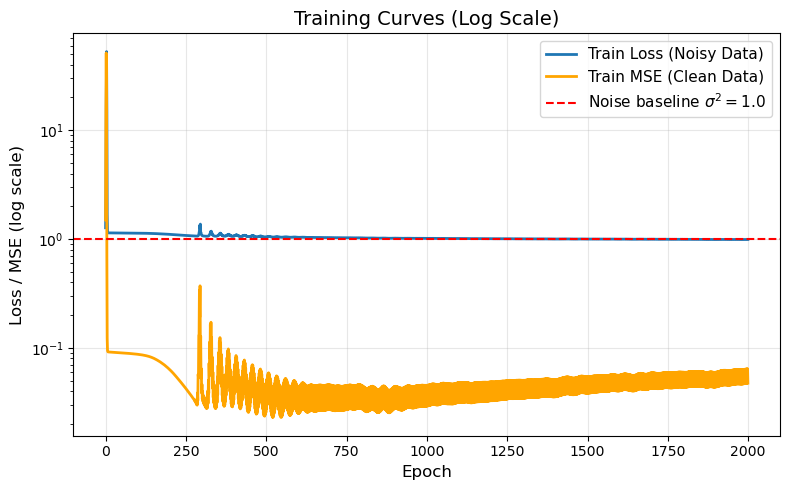

Final Results
Final Train Loss (noisy): 0.990410
Final Train MSE (clean): 0.047426


In [10]:
# Complete Example: Data Generation + Network Training

# Step 1: Set hyperparameters
d = 80          # Ambient dimension
m = 4           # Kernel size (local view size)
L =20           # Number of local views
K = 1024          # Network width (complexity)
N = 512         # Number of training samples
sigma = 1     # Noise level
random_seed = 42

# Step 2: Generate synthetic dataset
print("=" * 60)
print("Generating Synthetic Dataset")
print("=" * 60)
clean_dataset, noisy_dataset, H = generate_dataset_fast(d, 50, m, L, N, sigma, random_seed) # here K=10, the ground-true network is not that complex.
print(f"Dataset generated: {N} samples, dimension {d}")
print(f"Local views H shape: {H.shape}")
print(f"Example local view indices: {H[0]}")
print()

# Step 3: Create neural network model
print("=" * 60)
print("Creating Neural Network Model")
print("=" * 60)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = LocalViewNetwork(d=d, K=K, H=H)
print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")
print()

# Step 4: Train the network
print("=" * 60)
print("Training Neural Network")
print("=" * 60)
history = train_network(
    model=model,
    clean_dataset=clean_dataset,
    noisy_dataset=noisy_dataset,
    lr=0.4,                    # Learning rate
    weight_decay=0.0,           # L2 regularization
    batch_size=None,            # Full-batch gradient descent
    gradient_clip= 100,         # No gradient clipping
    epochs=2000,                # Number of epochs
    print_every=50,            # Print frequency
    device=device
)
print()

# Step 5: Plot training curves
print("=" * 60)
print("Plotting Training Curves")
print("=" * 60)
plot_training_curves(history)

# Step 6: Final evaluation
print("=" * 60)
print("Final Results")
print("=" * 60)
print(f"Final Train Loss (noisy): {history['train_loss'][-1]:.6f}")
print(f"Final Train MSE (clean): {history['train_mse'][-1]:.6f}")

Generating Synthetic Dataset
Dataset generated: 512 samples, dimension 800
Local views H shape: (20, 16)
Example local view indices: [ 50  92 141 149 157 183 197 277 383 461 480 530 535 746 758 765]

Creating Neural Network Model
Using device: cpu
Model created with 6409 parameters

Training Neural Network
Epoch    1/10000 | Train Loss (noisy): 1.315499 | Train MSE (clean): 0.000315
Epoch   50/10000 | Train Loss (noisy): 1.069188 | Train MSE (clean): 0.003856
Epoch  100/10000 | Train Loss (noisy): 1.061436 | Train MSE (clean): 0.004547
Epoch  150/10000 | Train Loss (noisy): 1.053117 | Train MSE (clean): 0.005911
Epoch  200/10000 | Train Loss (noisy): 1.055777 | Train MSE (clean): 0.005244
Epoch  250/10000 | Train Loss (noisy): 1.045453 | Train MSE (clean): 0.007308
Epoch  300/10000 | Train Loss (noisy): 1.050374 | Train MSE (clean): 0.006208
Epoch  350/10000 | Train Loss (noisy): 1.056466 | Train MSE (clean): 0.005122
Epoch  400/10000 | Train Loss (noisy): 1.040967 | Train MSE (clean):

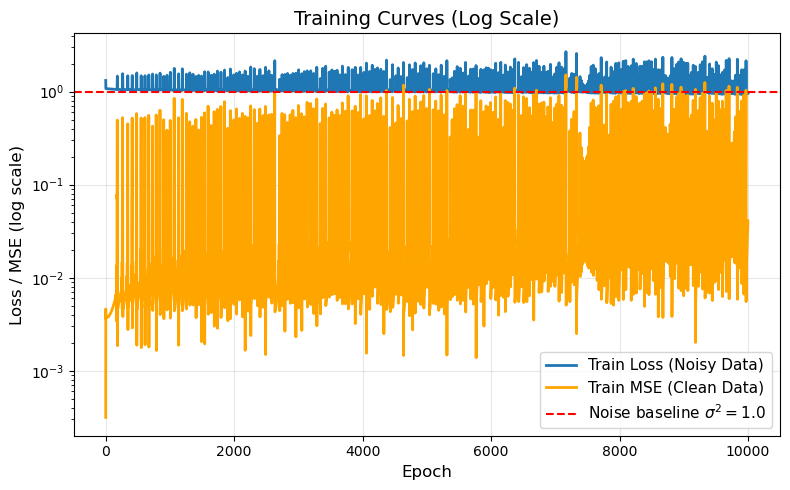

Final Results
Final Train Loss (noisy): 0.952835
Final Train MSE (clean): 0.040847


In [ ]:
# Complete Example: Data Generation + Network Training

# Step 1: Set hyperparameters
d = 800          # Ambient dimension
m =16           # Kernel size (local view size)
L =20           # Number of local views
K = 356          # Network width (complexity)
N = 512         # Number of training samples
sigma = 1     # Noise level
random_seed = 12

# Step 2: Generate synthetic dataset
print("=" * 60)
print("Generating Synthetic Dataset")
print("=" * 60)
clean_dataset, noisy_dataset, H = generate_dataset(d, 50, m, L, N, sigma, random_seed) # here K=50, the ground-true network is not that complex.
print(f"Dataset generated: {N} samples, dimension {d}")
print(f"Local views H shape: {H.shape}")
print(f"Example local view indices: {H[0]}")
print()

# Step 3: Create neural network model
print("=" * 60)
print("Creating Neural Network Model")
print("=" * 60)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = LocalViewNetwork(d=d, K=K, H=H)
print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")
print()

# Step 4: Train the network
print("=" * 60)
print("Training Neural Network")
print("=" * 60)
history = train_network(
    model=model,
    clean_dataset=clean_dataset,
    noisy_dataset=noisy_dataset,
    lr=0.4,                    # Learning rate
    weight_decay=0.0,           # L2 regularization
    batch_size=None,            # Full-batch gradient descent
    gradient_clip= 100,         # No gradient clipping
    epochs=10000,                # Number of epochs
    print_every=50,            # Print frequency
    device=device
)
print()

# Step 5: Plot training curves
print("=" * 60)
print("Plotting Training Curves")
print("=" * 60)
plot_training_curves(history)

# Step 6: Final evaluation
print("=" * 60)
print("Final Results")
print("=" * 60)
print(f"Final Train Loss (noisy): {history['train_loss'][-1]:.6f}")
print(f"Final Train MSE (clean): {history['train_mse'][-1]:.6f}")

Generating Synthetic Dataset
Dataset generated: 512 samples, dimension 800
Local views H shape: (100, 4)
Example local view indices: [200 488 757 777]

Creating Neural Network Model
Using device: cpu
Model created with 3073 parameters

Training Neural Network
Epoch    1/10000 | Train Loss (noisy): 2.080147 | Train MSE (clean): 0.055917
Epoch   50/10000 | Train Loss (noisy): 1.076394 | Train MSE (clean): 0.003695
Epoch  100/10000 | Train Loss (noisy): 1.074926 | Train MSE (clean): 0.003888
Epoch  150/10000 | Train Loss (noisy): 1.073503 | Train MSE (clean): 0.004179
Epoch  200/10000 | Train Loss (noisy): 1.072195 | Train MSE (clean): 0.004566
Epoch  250/10000 | Train Loss (noisy): 1.071022 | Train MSE (clean): 0.005027
Epoch  300/10000 | Train Loss (noisy): 1.069999 | Train MSE (clean): 0.005539
Epoch  350/10000 | Train Loss (noisy): 1.069091 | Train MSE (clean): 0.006026
Epoch  400/10000 | Train Loss (noisy): 1.075194 | Train MSE (clean): 0.002113
Epoch  450/10000 | Train Loss (noisy):

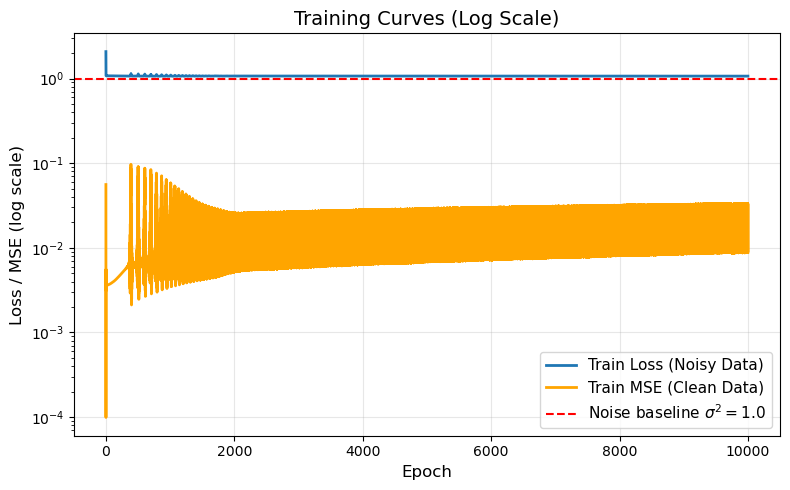

Final Results
Final Train Loss (noisy): 1.068387
Final Train MSE (clean): 0.008868


In [57]:
# Complete Example: Data Generation + Network Training

# Step 1: Set hyperparameters
d = 800          # Ambient dimension
m =4           # Kernel size (local view size)
L =100           # Number of local views
K = 512          # Network width (complexity)
N = 512         # Number of training samples
sigma = 1     # Noise level
random_seed = 12

# Step 2: Generate synthetic dataset
print("=" * 60)
print("Generating Synthetic Dataset")
print("=" * 60)
clean_dataset, noisy_dataset, H = generate_dataset(d, 50, m, L, N, sigma, random_seed) # here K=50, the ground-true network is not that complex.
print(f"Dataset generated: {N} samples, dimension {d}")
print(f"Local views H shape: {H.shape}")
print(f"Example local view indices: {H[0]}")
print()

# Step 3: Create neural network model
print("=" * 60)
print("Creating Neural Network Model")
print("=" * 60)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = LocalViewNetwork(d=d, K=K, H=H)
print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")
print()

# Step 4: Train the network
print("=" * 60)
print("Training Neural Network")
print("=" * 60)
history = train_network(
    model=model,
    clean_dataset=clean_dataset,
    noisy_dataset=noisy_dataset,
    lr=0.4,                    # Learning rate
    weight_decay=0.0,           # L2 regularization
    batch_size=None,            # Full-batch gradient descent
    gradient_clip= 100,         # No gradient clipping
    epochs=10000,                # Number of epochs
    print_every=50,            # Print frequency
    device=device
)
print()

# Step 5: Plot training curves
print("=" * 60)
print("Plotting Training Curves")
print("=" * 60)
plot_training_curves(history)

# Step 6: Final evaluation
print("=" * 60)
print("Final Results")
print("=" * 60)
print(f"Final Train Loss (noisy): {history['train_loss'][-1]:.6f}")
print(f"Final Train MSE (clean): {history['train_mse'][-1]:.6f}")

Generating Synthetic Dataset
Dataset generated: 512 samples, dimension 800
Local views H shape: (20, 4)
Example local view indices: [ 71 351 523 617]

Creating Neural Network Model
Using device: cpu
Model created with 6145 parameters

Training Neural Network
Epoch    1/5000 | Train Loss (noisy): 0.533362 | Train MSE (clean): 0.029977
Epoch   50/5000 | Train Loss (noisy): 0.260326 | Train MSE (clean): 0.000357
Epoch  100/5000 | Train Loss (noisy): 0.259217 | Train MSE (clean): 0.000669
Epoch  150/5000 | Train Loss (noisy): 0.258444 | Train MSE (clean): 0.001002
Epoch  200/5000 | Train Loss (noisy): 0.257846 | Train MSE (clean): 0.001282
Epoch  250/5000 | Train Loss (noisy): 0.257344 | Train MSE (clean): 0.001506
Epoch  300/5000 | Train Loss (noisy): 0.256905 | Train MSE (clean): 0.001693
Epoch  350/5000 | Train Loss (noisy): 0.256511 | Train MSE (clean): 0.001854
Epoch  400/5000 | Train Loss (noisy): 0.256154 | Train MSE (clean): 0.001993
Epoch  450/5000 | Train Loss (noisy): 0.255821 |

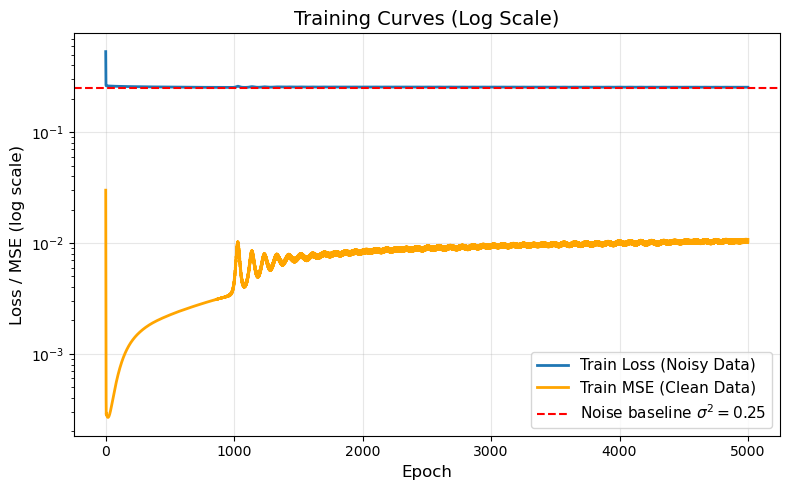

Final Results
Final Train Loss (noisy): 0.254658
Final Train MSE (clean): 0.010786


In [59]:
# Complete Example: Data Generation + Network Training

# Step 1: Set hyperparameters
d = 800          # Ambient dimension
m =4           # Kernel size (local view size)
L =20           # Number of local views
K = 1024          # Network width (complexity)
N = 512         # Number of training samples
sigma = 0.5     # Noise level
random_seed = 42

# Step 2: Generate synthetic dataset
print("=" * 60)
print("Generating Synthetic Dataset")
print("=" * 60)
clean_dataset, noisy_dataset, H = generate_dataset(d, 50, m, L, N, sigma, random_seed) # here K=10, the ground-true network is not that complex.
print(f"Dataset generated: {N} samples, dimension {d}")
print(f"Local views H shape: {H.shape}")
print(f"Example local view indices: {H[0]}")
print()

# Step 3: Create neural network model
print("=" * 60)
print("Creating Neural Network Model")
print("=" * 60)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = LocalViewNetwork(d=d, K=K, H=H)
print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")
print()

# Step 4: Train the network
print("=" * 60)
print("Training Neural Network")
print("=" * 60)
history = train_network(
    model=model,
    clean_dataset=clean_dataset,
    noisy_dataset=noisy_dataset,
    lr=0.4,                    # Learning rate
    weight_decay=0.0,           # L2 regularization
    batch_size=None,            # Full-batch gradient descent
    gradient_clip= 100,         # No gradient clipping
    epochs=5000,                # Number of epochs
    print_every=50,            # Print frequency
    device=device
)
print()

# Step 5: Plot training curves
print("=" * 60)
print("Plotting Training Curves")
print("=" * 60)
plot_training_curves(history, sigma=sigma)

# Step 6: Final evaluation
print("=" * 60)
print("Final Results")
print("=" * 60)
print(f"Final Train Loss (noisy): {history['train_loss'][-1]:.6f}")
print(f"Final Train MSE (clean): {history['train_mse'][-1]:.6f}")

Generating Synthetic Dataset
Dataset generated: 512 samples, dimension 800
Local views H shape: (20, 4)
Example local view indices: [ 71 351 523 617]

Creating Neural Network Model
Using device: cpu
Model created with 6145 parameters

Training Neural Network
Epoch    1/40000 | Train Loss (noisy): 1.453078 | Train MSE (clean): 0.187058
Epoch   50/40000 | Train Loss (noisy): 1.042693 | Train MSE (clean): 0.000554
Epoch  100/40000 | Train Loss (noisy): 1.041129 | Train MSE (clean): 0.000812
Epoch  150/40000 | Train Loss (noisy): 1.039793 | Train MSE (clean): 0.001137
Epoch  200/40000 | Train Loss (noisy): 1.038646 | Train MSE (clean): 0.001503
Epoch  250/40000 | Train Loss (noisy): 1.037636 | Train MSE (clean): 0.001892
Epoch  300/40000 | Train Loss (noisy): 1.036738 | Train MSE (clean): 0.002290
Epoch  350/40000 | Train Loss (noisy): 1.035934 | Train MSE (clean): 0.002685
Epoch  400/40000 | Train Loss (noisy): 1.035207 | Train MSE (clean): 0.003070
Epoch  450/40000 | Train Loss (noisy): 

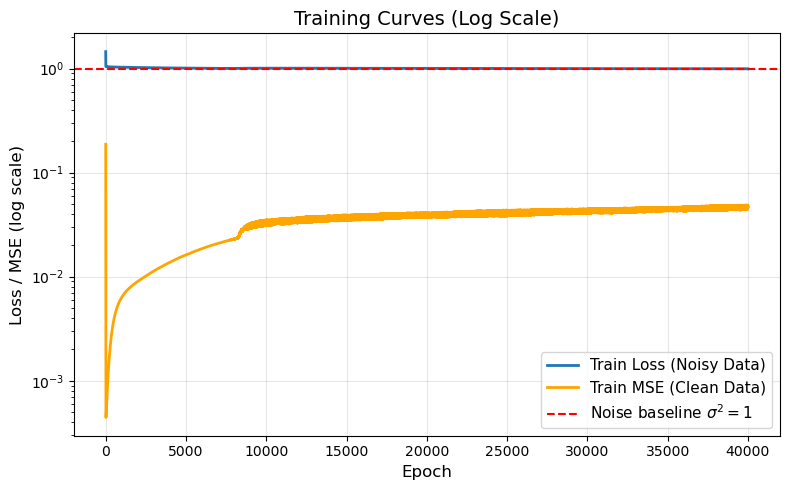

Final Results
Final Train Loss (noisy): 0.994337
Final Train MSE (clean): 0.047363


In [61]:
# Complete Example: Data Generation + Network Training

# Step 1: Set hyperparameters
d = 800          # Ambient dimension
m =4           # Kernel size (local view size)
L =20           # Number of local views
K = 1024          # Network width (complexity)
N = 512         # Number of training samples
sigma = 1     # Noise level
random_seed = 42

# Step 2: Generate synthetic dataset
print("=" * 60)
print("Generating Synthetic Dataset")
print("=" * 60)
clean_dataset, noisy_dataset, H = generate_dataset(d, 50, m, L, N, sigma, random_seed) # here K=10, the ground-true network is not that complex.
print(f"Dataset generated: {N} samples, dimension {d}")
print(f"Local views H shape: {H.shape}")
print(f"Example local view indices: {H[0]}")
print()

# Step 3: Create neural network model
print("=" * 60)
print("Creating Neural Network Model")
print("=" * 60)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = LocalViewNetwork(d=d, K=K, H=H)
print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")
print()

# Step 4: Train the network
print("=" * 60)
print("Training Neural Network")
print("=" * 60)
history = train_network(
    model=model,
    clean_dataset=clean_dataset,
    noisy_dataset=noisy_dataset,
    lr=0.1,                    # Learning rate
    weight_decay=0.0,           # L2 regularization
    batch_size=None,            # Full-batch gradient descent
    gradient_clip= 100,         # No gradient clipping
    epochs=40000,                # Number of epochs
    print_every=50,            # Print frequency
    device=device
)
print()

# Step 5: Plot training curves
print("=" * 60)
print("Plotting Training Curves")
print("=" * 60)
plot_training_curves(history, sigma=sigma)

# Step 6: Final evaluation
print("=" * 60)
print("Final Results")
print("=" * 60)
print(f"Final Train Loss (noisy): {history['train_loss'][-1]:.6f}")
print(f"Final Train MSE (clean): {history['train_mse'][-1]:.6f}")

Generating Synthetic Dataset
Dataset generated: 512 samples, dimension 800
Local views H shape: (20, 4)
Example local view indices: [ 71 351 523 617]

Creating Neural Network Model
Using device: cpu
Model created with 6145 parameters

Training Neural Network
Epoch    1/40000 | Train Loss (noisy): 1.339673 | Train MSE (clean): 0.209373
Epoch   50/40000 | Train Loss (noisy): 1.044396 | Train MSE (clean): 0.000357
Epoch  100/40000 | Train Loss (noisy): 1.043433 | Train MSE (clean): 0.000432
Epoch  150/40000 | Train Loss (noisy): 1.042549 | Train MSE (clean): 0.000540
Epoch  200/40000 | Train Loss (noisy): 1.041730 | Train MSE (clean): 0.000676
Epoch  250/40000 | Train Loss (noisy): 1.040972 | Train MSE (clean): 0.000833
Epoch  300/40000 | Train Loss (noisy): 1.040268 | Train MSE (clean): 0.001010
Epoch  350/40000 | Train Loss (noisy): 1.039618 | Train MSE (clean): 0.001199
Epoch  400/40000 | Train Loss (noisy): 1.039012 | Train MSE (clean): 0.001400
Epoch  450/40000 | Train Loss (noisy): 

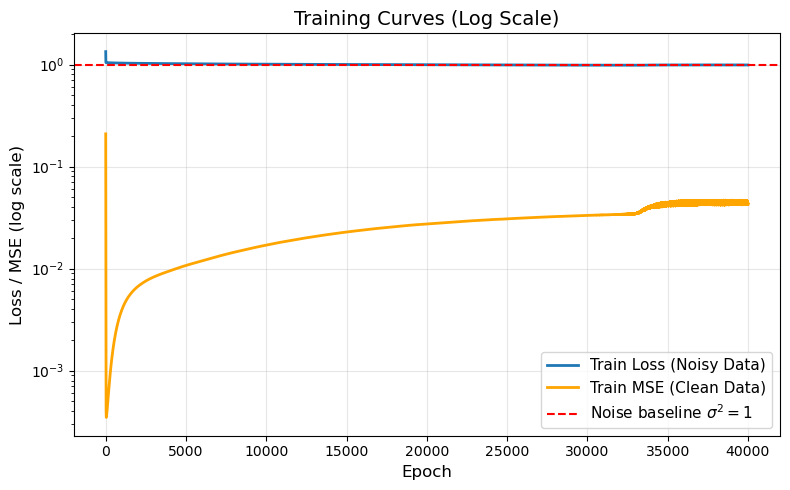

Final Results
Final Train Loss (noisy): 0.990211
Final Train MSE (clean): 0.042568


In [ ]:
# Complete Example: Data Generation + Network Training

# Step 1: Set hyperparameters
d = 800          # Ambient dimension
m =4           # Kernel size (local view size)
L =20           # Number of local views
K = 1024          # Network width (complexity)
N = 512         # Number of training samples
sigma = 1     # Noise level
random_seed = 42

# Step 2: Generate synthetic dataset
print("=" * 60)
print("Generating Synthetic Dataset")
print("=" * 60)
clean_dataset, noisy_dataset, H = generate_dataset(d, 50, m, L, N, sigma, random_seed) # here K=10, the ground-true network is not that complex.
print(f"Dataset generated: {N} samples, dimension {d}")
print(f"Local views H shape: {H.shape}")
print(f"Example local view indices: {H[0]}")
print()

# Step 3: Create neural network model
print("=" * 60)
print("Creating Neural Network Model")
print("=" * 60)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = LocalViewNetwork(d=d, K=K, H=H)
print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")
print()

# Step 4: Train the network
print("=" * 60)
print("Training Neural Network")
print("=" * 60)
history = train_network(
    model=model,
    clean_dataset=clean_dataset,
    noisy_dataset=noisy_dataset,
    lr=0.05,                    # Learning rate
    weight_decay=0.0,           # L2 regularization
    batch_size=None,            # Full-batch gradient descent
    gradient_clip= 100,         # No gradient clipping
    epochs=40000,                # Number of epochs
    print_every=50,            # Print frequency
    device=device
)
print()

# Step 5: Plot training curves
print("=" * 60)
print("Plotting Training Curves")
print("=" * 60)
plot_training_curves(history, sigma=sigma)

# Step 6: Final evaluation
print("=" * 60)
print("Final Results")
print("=" * 60)
print(f"Final Train Loss (noisy): {history['train_loss'][-1]:.6f}")
print(f"Final Train MSE (clean): {history['train_mse'][-1]:.6f}")

## Experiment on patch-correlation

Consider $X \sim \mathbb{R}^{Lm}$, so that we have a collection of $L$ disjoint local views of dimension $m$ very naturally. Let $H(m,L)^{disc}$ be this view and for $h\ in H(m,L)$, let $X_h$ be the local view of $h$ i.e. $\pi_h(X)$. Formally, we have
$$
 X=\mathrm{Concat}_{h\in H(m,l)}{X_h}   
$$

Now consider a dataset, where the input feature is of the form $X_h=X_{h'}$ for any two $h,h'\in H_{m,L}$ and $X_h$ is sampled from unit sphere $S^{m-1}$. The teacher function is the same as we did previously. Now train neural network in the same paradigm.

In [ ]:
  # Modified Data Generation for Patch-Correlation Experiment
# Key difference: All local views are IDENTICAL (replicated patches)

def generate_dataset_identical_patches(
    d: int, 
    K: int, 
    m: int, 
    L: int, 
    N: int, 
    sigma: float, 
    random_seed: int
):
    """
    Generate synthetic dataset where ALL local views are IDENTICAL.
    
    In this setup:
    - Input X ∈ R^(L×m) where d = L×m
    - X = Concat(X_h, X_h, ..., X_h) - same patch repeated L times
    - Each X_h is sampled from unit sphere S^(m-1)
    
    This tests how the network handles perfectly correlated patches.
    
    Args:
        d: Ambient dimension (must equal L×m for this experiment)
        K: Width of ground truth network
        m: Size of each local view (patch size)
        L: Number of local views (number of patches)
        N: Number of samples
        sigma: Noise standard deviation for labels
        random_seed: Random seed
    
    Returns:
        clean_dataset: Array of shape (N, d+1), where last column is f(x_i)
        noisy_dataset: Array of shape (N, d+1), where last column is y_i = f(x_i) + noise
        H: Local view indices, shape (L, m) - disjoint consecutive blocks
    """
    assert d == L * m, f"For this experiment, d must equal L×m. Got d={d}, L×m={L*m}"
    
    rng = np.random.default_rng(random_seed)
    
    # Generate local views H as consecutive disjoint blocks
    # H[0] = [0, 1, ..., m-1]
    # H[1] = [m, m+1, ..., 2m-1]
    # ...
    # H[L-1] = [(L-1)m, ..., Lm-1]
    H = np.array([np.arange(i*m, (i+1)*m) for i in range(L)])
    
    # Create ground truth function (batch version)
    f = ground_true_function_batch(d, K, H, random_seed)
    
    # Generate N samples with IDENTICAL patches
    X = np.zeros((N, d))
    for i in range(N):
        # Sample one patch from unit sphere S^(m-1)
        patch = rng.normal(0, 1, m)
        patch = patch / np.linalg.norm(patch)  # Normalize to unit sphere
        
        # Replicate this patch L times to form the full input
        for j in range(L):
            X[i, j*m:(j+1)*m] = patch
    
    # Verify that all patches are identical (sanity check)
    for i in range(N):
        for j in range(1, L):
            assert np.allclose(X[i, 0:m], X[i, j*m:(j+1)*m]), \
                f"Patches should be identical! Sample {i}, patch {j}"
    
    # Generate clean labels: f(X) - BATCH PROCESSING
    f_X = f(X)  # Shape: (N,)
    
    # Generate noisy labels: y_i = f(x_i) + N(0, sigma^2)
    noise = rng.normal(0, sigma, N)
    y = f_X + noise
    
    # Combine features and labels
    clean_dataset = np.concatenate([X, f_X[:, None]], axis=1)
    noisy_dataset = np.concatenate([X, y[:, None]], axis=1)
    
    return clean_dataset, noisy_dataset, H


def run_identical_patches_experiment(
    m: int,
    L: int,
    K: int,
    N: int,
    sigma: float = 1.0,
    K_ground_truth: int = 50,
    lr: float = 0.1,
    epochs: int = 2000,
    print_every: int = 100,
    random_seed: int = 42
):
    """
    Run complete experiment with identical patches setup.
    
    Args:
        m: Patch size (dimension of each local view)
        L: Number of patches (all identical)
        K: Network width (learner complexity)
        N: Number of training samples
        sigma: Noise level
        K_ground_truth: Width of ground truth network
        lr: Learning rate
        epochs: Number of training epochs
        print_every: Print frequency
        random_seed: Random seed
    """
    # Set d = L × m (required for this experiment)
    d = L * m
    
    print("=" * 70)
    print("PATCH-CORRELATION EXPERIMENT: All Patches Identical")
    print("=" * 70)
    print(f"Setup:")
    print(f"  - Patch size (m): {m}")
    print(f"  - Number of patches (L): {L}")
    print(f"  - Ambient dimension (d = L×m): {d}")
    print(f"  - Network width (K): {K}")
    print(f"  - Ground truth width: {K_ground_truth}")
    print(f"  - Number of samples (N): {N}")
    print(f"  - Noise level (σ): {sigma}")
    print()
    print("KEY: All L patches are IDENTICAL copies of the same m-dimensional vector!")
    print()
    
    # Step 1: Generate dataset with identical patches
    print("-" * 70)
    print("Step 1: Generating Dataset")
    print("-" * 70)
    clean_dataset, noisy_dataset, H = generate_dataset_identical_patches(
        d, K_ground_truth, m, L, N, sigma, random_seed
    )
    print(f"✓ Dataset generated: {N} samples, dimension {d}")
    print(f"✓ Local views H shape: {H.shape}")
    print(f"✓ Example: H[0] = {H[0]}, H[1] = {H[1]}")
    
    # Verify patch identity
    X_sample = clean_dataset[0, :-1]
    print(f"✓ Verification: All patches identical in sample 0?")
    for i in range(L):
        patch_i = X_sample[i*m:(i+1)*m]
        if i == 0:
            first_patch = patch_i
        else:
            assert np.allclose(patch_i, first_patch), "Patches should be identical!"
    print(f"  YES - All {L} patches are identical!")
    print()
    
    # Step 2: Create neural network
    print("-" * 70)
    print("Step 2: Creating Neural Network")
    print("-" * 70)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {device}")
    
    model = LocalViewNetwork(d=d, K=K, H=H)
    num_params = sum(p.numel() for p in model.parameters())
    print(f"✓ Model created with {num_params:,} parameters")
    print()
    
    # Step 3: Train network
    print("-" * 70)
    print("Step 3: Training Neural Network")
    print("-" * 70)
    history = train_network(
        model=model,
        clean_dataset=clean_dataset,
        noisy_dataset=noisy_dataset,
        lr=lr,
        weight_decay=0.0,
        batch_size=None,  # Full-batch GD
        gradient_clip=100,
        epochs=epochs,
        print_every=print_every,
        device=device
    )
    print()
    
    # Step 4: Plot results
    print("-" * 70)
    print("Step 4: Plotting Training Curves")
    print("-" * 70)
    plot_training_curves(history, sigma=sigma)
    
    # Step 5: Final evaluation
    print("-" * 70)
    print("Final Results")
    print("-" * 70)
    print(f"Final Train Loss (noisy): {history['train_loss'][-1]:.6f}")
    print(f"Final Train MSE (clean): {history['train_mse'][-1]:.6f}")
    print(f"Noise baseline (σ²): {sigma**2:.6f}")
    
    # Check if model fit the data well
    if history['train_mse'][-1] < sigma**2 / 10:
        print("\n✓ Model successfully learned the ground truth function!")
    else:
        print("\n⚠ Model may not have fully converged or has difficulty learning.")
    
    return {
        'history': history,
        'model': model,
        'clean_dataset': clean_dataset,
        'noisy_dataset': noisy_dataset,
        'H': H
    }



PATCH-CORRELATION EXPERIMENT: All Patches Identical
Setup:
  - Patch size (m): 9
  - Number of patches (L): 10
  - Ambient dimension (d = L×m): 90
  - Network width (K): 1024
  - Ground truth width: 50
  - Number of samples (N): 512
  - Noise level (σ): 1.0

KEY: All L patches are IDENTICAL copies of the same m-dimensional vector!

----------------------------------------------------------------------
Step 1: Generating Dataset
----------------------------------------------------------------------
✓ Dataset generated: 512 samples, dimension 90
✓ Local views H shape: (10, 9)
✓ Example: H[0] = [0 1 2 3 4 5 6 7 8], H[1] = [ 9 10 11 12 13 14 15 16 17]
✓ Verification: All patches identical in sample 0?
  YES - All 10 patches are identical!

----------------------------------------------------------------------
Step 2: Creating Neural Network
----------------------------------------------------------------------
Device: cpu
✓ Model created with 11,265 parameters

----------------------------

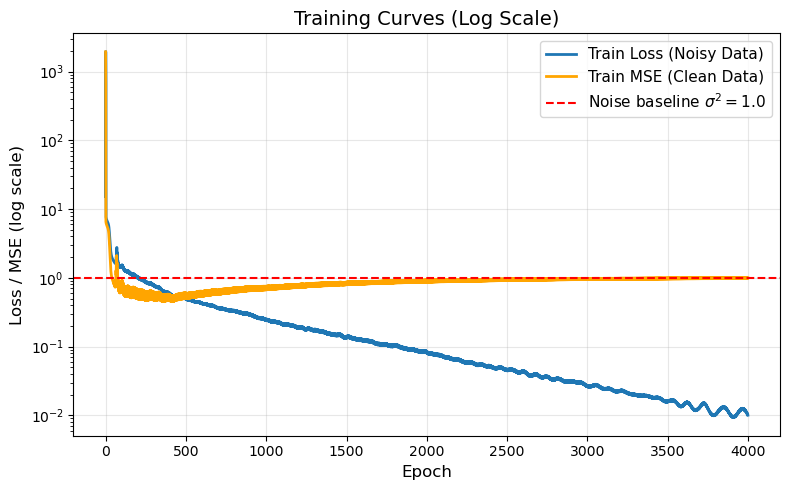

----------------------------------------------------------------------
Final Results
----------------------------------------------------------------------
Final Train Loss (noisy): 0.010053
Final Train MSE (clean): 1.000278
Noise baseline (σ²): 1.000000

⚠ Model may not have fully converged or has difficulty learning.


In [21]:
# Example 1: Run single experiment with identical patches
result = run_identical_patches_experiment(
    m=9,           # Patch size
    L=10,          # Number of identical patches
    K=1024,        # Network width
    N=512,         # Number of samples
    sigma=1.0,     # Noise level
    K_ground_truth=50,  # Ground truth complexity
    lr=0.2,        # Learning rate
    epochs=4000,  # Training epochs
    print_every=200,
    random_seed=42
)

In [18]:
# Experiment: Periodic Input + Augmented Local Views (Disjoint + Random)

def generate_augmented_local_views(d: int, m: int, L: int, R: int, random_seed: int) -> np.ndarray:
    """
    Generate augmented local views: H = H_disjoint(m,L) ∪ H_random(R)
    
    Args:
        d: Ambient dimension (should be L×m)
        m: Patch size
        L: Number of disjoint consecutive blocks
        R: Number of additional random views
        random_seed: Random seed
    
    Returns:
        H: Array of shape (L+R, m) containing both disjoint and random views
    """
    assert d == L * m, f"d must equal L×m. Got d={d}, L×m={L*m}"
    
    rng = np.random.default_rng(random_seed)
    
    # Part 1: Disjoint consecutive blocks H(m,L)
    H_disjoint = np.array([np.arange(i*m, (i+1)*m) for i in range(L)])
    
    # Part 2: R random local views H_random(R)
    H_random = []
    for _ in range(R):
        indices = np.sort(rng.choice(d, size=m, replace=False))
        H_random.append(indices)
    H_random = np.array(H_random)
    
    # Combine: H = H_disjoint ∪ H_random
    H = np.vstack([H_disjoint, H_random])
    
    return H, H_disjoint, H_random


def generate_dataset_augmented_views(
    m: int,
    L: int,
    R: int,
    K: int,
    N: int,
    sigma: float,
    random_seed: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate dataset with:
    - Input: Periodic identical patches (dimension L×m)
    - Local views: H = H_disjoint(m,L) ∪ H_random(R)
    
    Args:
        m: Patch size
        L: Number of periodic repetitions (and disjoint views)
        R: Number of additional random views
        K: Width of ground truth network
        N: Number of samples
        sigma: Noise level
        random_seed: Random seed
    
    Returns:
        clean_dataset, noisy_dataset, H (augmented local views)
    """
    d = L * m
    rng = np.random.default_rng(random_seed)
    
    # Generate augmented local views
    H, H_disjoint, H_random = generate_augmented_local_views(d, m, L, R, random_seed)
    total_views = L + R
    
    print(f"Generated {total_views} local views:")
    print(f"  - {L} disjoint consecutive blocks")
    print(f"  - {R} random views")
    
    # Create ground truth function with augmented views
    f = ground_true_function_batch(d, K, H, random_seed)
    
    # Generate N samples with IDENTICAL PERIODIC patches (input unchanged)
    X = np.zeros((N, d))
    for i in range(N):
        # Sample one patch from unit sphere
        patch = rng.normal(0, 1, m)
        patch = patch / np.linalg.norm(patch)
        
        # Replicate L times (periodic structure)
        for j in range(L):
            X[i, j*m:(j+1)*m] = patch
    
    # Generate labels
    f_X = f(X)
    noise = rng.normal(0, sigma, N)
    y = f_X + noise
    
    clean_dataset = np.concatenate([X, f_X[:, None]], axis=1)
    noisy_dataset = np.concatenate([X, y[:, None]], axis=1)
    
    return clean_dataset, noisy_dataset, H


def run_augmented_views_experiment(
    m: int = 4,
    L: int = 20,
    R: int = 10,
    K: int = 1024,
    N: int = 512,
    sigma: float = 1.0,
    K_ground_truth: int = 50,
    lr: float = 0.1,
    epochs: int = 20000,
    print_every: int = 200,
    random_seed: int = 42
):
    """
    Run experiment with augmented local views.
    
    Key setup:
    - Input: Periodic identical patches (dimension L×m)
    - Local views: H = H_disjoint(m,L) ∪ H_random(R)
    - Both teacher and network use the same augmented H
    """
    d = L * m
    total_views = L + R
    
    print("=" * 70)
    print("AUGMENTED LOCAL VIEWS EXPERIMENT")
    print("=" * 70)
    print(f"Input structure: Periodic identical patches")
    print(f"  - Patch size (m): {m}")
    print(f"  - Repetitions (L): {L}")
    print(f"  - Input dimension (d = L×m): {d}")
    print()
    print(f"Local view structure: H = H_disjoint ∪ H_random")
    print(f"  - Disjoint consecutive views: {L}")
    print(f"  - Random views: {R}")
    print(f"  - Total views: {total_views}")
    print()
    print(f"Network: width K={K}, ground truth K={K_ground_truth}")
    print(f"Training: N={N} samples, σ={sigma}, lr={lr}, epochs={epochs}")
    print("=" * 70)
    print()
    
    # Generate dataset
    clean_dataset, noisy_dataset, H = generate_dataset_augmented_views(
        m, L, R, K_ground_truth, N, sigma, random_seed
    )
    
    print(f"\n✓ Dataset generated")
    print(f"✓ Total local views: {H.shape[0]}")
    print(f"✓ Example disjoint views:")
    print(f"    H[0] = {H[0]}")
    print(f"    H[1] = {H[1]}")
    print(f"✓ Example random views:")
    print(f"    H[{L}] = {H[L]}")
    if R > 1:
        print(f"    H[{L+1}] = {H[L+1]}")
    print()
    
    # Create and train network
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = LocalViewNetwork(d=d, K=K, H=H)
    print(f"✓ Model created: {sum(p.numel() for p in model.parameters()):,} parameters")
    print(f"✓ Device: {device}\n")
    
    print("Training...")
    history = train_network(
        model=model,
        clean_dataset=clean_dataset,
        noisy_dataset=noisy_dataset,
        lr=lr,
        weight_decay=0.0,
        batch_size=None,
        gradient_clip=100,
        epochs=epochs,
        print_every=print_every,
        device=device
    )
    
    # Plot results
    plot_training_curves(history, sigma=sigma)
    
    # Summary
    print("\n" + "=" * 70)
    print("FINAL RESULTS")
    print("=" * 70)
    print(f"Final Train Loss: {history['train_loss'][-1]:.6f}")
    print(f"Final Train MSE:  {history['train_mse'][-1]:.6f}")
    print(f"Noise baseline (σ²): {sigma**2:.6f}")
    
    return {
        'history': history,
        'model': model,
        'H': H,
        'num_views': total_views,
        'num_disjoint': L,
        'num_random': R
    }

In [ ]:
# Strided Local View Experiment with Overlapping Patches

def generate_strided_local_views(d: int, m: int, stride: int) -> np.ndarray:
    """
    Generate overlapping local views with a given stride.
    
    Args:
        d: Ambient dimension
        m: Patch size (kernel size)
        stride: Step size between consecutive patches
    
    Returns:
        H: Array of shape (L, m) where each row contains m indices
           Consecutive patches overlap by (m - stride) coordinates
    
    Example:
        d=10, m=4, stride=3:
        H[0] = [0,1,2,3]
        H[1] = [3,4,5,6]  # overlaps by 1 coordinate
        H[2] = [6,7,8,9]
    """
    H = []
    start = 0
    while start + m <= d:
        H.append(np.arange(start, start + m))
        start += stride
    
    return np.array(H)


def generate_dataset_strided_identical_patches(
    m: int,
    L: int, 
    stride: int,
    K: int,
    N: int, 
    sigma: float, 
    random_seed: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate dataset with:
    - Input: identical periodic patches (same as before)
    - Local views: strided overlapping patches
    
    Args:
        m: Patch size
        L: Number of periodic repetitions in input
        stride: Stride for local views
        K: Width of ground truth network
        N: Number of samples
        sigma: Noise level
        random_seed: Random seed
    
    Returns:
        clean_dataset, noisy_dataset, H (strided local views)
    """
    # Input dimension (periodic identical patches)
    d = L * m
    
    rng = np.random.default_rng(random_seed)
    
    # Generate STRIDED local views (overlapping patches)
    H = generate_strided_local_views(d, m, stride)
    L_views = H.shape[0]  # Actual number of local views
    
    print(f"Generated {L_views} overlapping views with stride={stride}")
    print(f"Overlap per consecutive patch: {m - stride} coordinates")
    
    # Create ground truth function with strided views
    f = ground_true_function_batch(d, K, H, random_seed)
    
    # Generate N samples with IDENTICAL PERIODIC patches (input unchanged)
    X = np.zeros((N, d))
    for i in range(N):
        # Sample one patch from unit sphere
        patch = rng.normal(0, 1, m)
        patch = patch / np.linalg.norm(patch)
        
        # Replicate L times (periodic structure)
        for j in range(L):
            X[i, j*m:(j+1)*m] = patch
    
    # Generate labels
    f_X = f(X)
    noise = rng.normal(0, sigma, N)
    y = f_X + noise
    
    clean_dataset = np.concatenate([X, f_X[:, None]], axis=1)
    noisy_dataset = np.concatenate([X, y[:, None]], axis=1)
    
    return clean_dataset, noisy_dataset, H


def run_strided_experiment(
    m: int = 4,
    L: int = 20,
    stride: int = 3,
    K: int = 1024,
    N: int = 512,
    sigma: float = 1.0,
    K_ground_truth: int = 50,
    lr: float = 0.1,
    epochs: int = 20000,
    print_every: int = 200,
    random_seed: int = 42
):
    """
    Run strided overlapping patches experiment.
    
    Key setup:
    - Input: Periodic identical patches (dimension L×m)
    - Local views: Strided with overlap (both teacher and network use same views)
    """
    d = L * m
    
    print("=" * 70)
    print("STRIDED OVERLAPPING PATCHES EXPERIMENT")
    print("=" * 70)
    print(f"Input structure: Periodic identical patches")
    print(f"  - Patch size (m): {m}")
    print(f"  - Repetitions (L): {L}")
    print(f"  - Input dimension (d = L×m): {d}")
    print()
    print(f"Local view structure: Strided overlapping")
    print(f"  - Patch size (m): {m}")
    print(f"  - Stride: {stride}")
    print(f"  - Overlap: {m - stride} coordinates per consecutive patch")
    print()
    print(f"Network: width K={K}, ground truth K={K_ground_truth}")
    print(f"Training: N={N} samples, σ={sigma}, lr={lr}, epochs={epochs}")
    print("=" * 70)
    print()
    
    # Generate dataset
    clean_dataset, noisy_dataset, H = generate_dataset_strided_identical_patches(
        m, L, stride, K_ground_truth, N, sigma, random_seed
    )
    
    L_views = H.shape[0]
    print(f"\n✓ Dataset generated")
    print(f"✓ Number of overlapping views: {L_views}")
    print(f"✓ Example views:")
    print(f"    H[0] = {H[0]}")
    print(f"    H[1] = {H[1]} (overlap: {np.intersect1d(H[0], H[1])})")
    if L_views > 2:
        print(f"    H[2] = {H[2]} (overlap: {np.intersect1d(H[1], H[2])})")
    print()
    
    # Create and train network
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = LocalViewNetwork(d=d, K=K, H=H)
    print(f"✓ Model created: {sum(p.numel() for p in model.parameters()):,} parameters")
    print(f"✓ Device: {device}\n")
    
    print("Training...")
    history = train_network(
        model=model,
        clean_dataset=clean_dataset,
        noisy_dataset=noisy_dataset,
        lr=lr,
        weight_decay=0.0,
        batch_size=None,
        gradient_clip=100,
        epochs=epochs,
        print_every=print_every,
        device=device
    )
    
    # Plot results
    plot_training_curves(history, sigma=sigma)
    
    # Summary
    print("\n" + "=" * 70)
    print("FINAL RESULTS")
    print("=" * 70)
    print(f"Final Train Loss: {history['train_loss'][-1]:.6f}")
    print(f"Final Train MSE:  {history['train_mse'][-1]:.6f}")
    print(f"Noise baseline (σ²): {sigma**2:.6f}")
    
    return {
        'history': history,
        'model': model,
        'H': H,
        'num_views': L_views
    }

AUGMENTED LOCAL VIEWS EXPERIMENT
Input structure: Periodic identical patches
  - Patch size (m): 9
  - Repetitions (L): 10
  - Input dimension (d = L×m): 90

Local view structure: H = H_disjoint ∪ H_random
  - Disjoint consecutive views: 10
  - Random views: 40
  - Total views: 50

Network: width K=1024, ground truth K=50
Training: N=512 samples, σ=1.0, lr=0.2, epochs=4000

Generated 50 local views:
  - 10 disjoint consecutive blocks
  - 40 random views

✓ Dataset generated
✓ Total local views: 50
✓ Example disjoint views:
    H[0] = [0 1 2 3 4 5 6 7 8]
    H[1] = [ 9 10 11 12 13 14 15 16 17]
✓ Example random views:
    H[10] = [ 7 18 37 54 62 64 74 85 87]
    H[11] = [10 15 31 37 42 57 69 81 88]

✓ Model created: 11,265 parameters
✓ Device: cpu

Training...
Epoch    1/4000 | Train Loss (noisy): 9.749788 | Train MSE (clean): 1490.185303
Epoch  200/4000 | Train Loss (noisy): 1.088277 | Train MSE (clean): 0.116635
Epoch  400/4000 | Train Loss (noisy): 1.012903 | Train MSE (clean): 0.0699

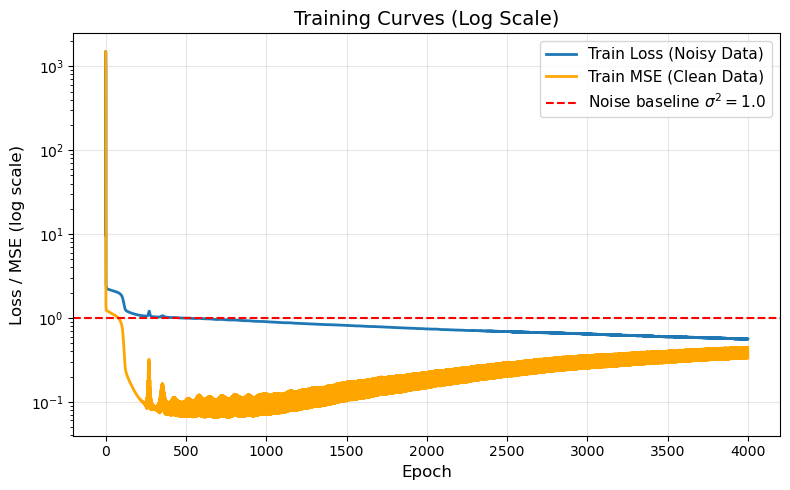


FINAL RESULTS
Final Train Loss: 0.561276
Final Train MSE:  0.334068
Noise baseline (σ²): 1.000000


In [23]:
# Run the augmented views experiment
result = run_augmented_views_experiment(
    m=9,              # Patch size
    L=10,             # Number of disjoint views (and periodic repetitions)
    R=40,             # Number of additional random views
    K=1024,           # Network width
    N=512,            # Number of samples
    sigma=1.0,        # Noise level
    K_ground_truth=50,
    lr=0.2,
    epochs=4000,
    print_every=200,
    random_seed=42
)

AUGMENTED LOCAL VIEWS EXPERIMENT
Input structure: Periodic identical patches
  - Patch size (m): 9
  - Repetitions (L): 10
  - Input dimension (d = L×m): 90

Local view structure: H = H_disjoint ∪ H_random
  - Disjoint consecutive views: 10
  - Random views: 20
  - Total views: 30

Network: width K=1024, ground truth K=50
Training: N=512 samples, σ=1.0, lr=0.2, epochs=4000

Generated 30 local views:
  - 10 disjoint consecutive blocks
  - 20 random views

✓ Dataset generated
✓ Total local views: 30
✓ Example disjoint views:
    H[0] = [0 1 2 3 4 5 6 7 8]
    H[1] = [ 9 10 11 12 13 14 15 16 17]
✓ Example random views:
    H[10] = [ 7 18 37 54 62 64 74 85 87]
    H[11] = [10 15 31 37 42 57 69 81 88]

✓ Model created: 11,265 parameters
✓ Device: cpu

Training...
Epoch    1/4000 | Train Loss (noisy): 9.978511 | Train MSE (clean): 1484.758301
Epoch  200/4000 | Train Loss (noisy): 1.042114 | Train MSE (clean): 0.119948
Epoch  400/4000 | Train Loss (noisy): 0.930694 | Train MSE (clean): 0.1099

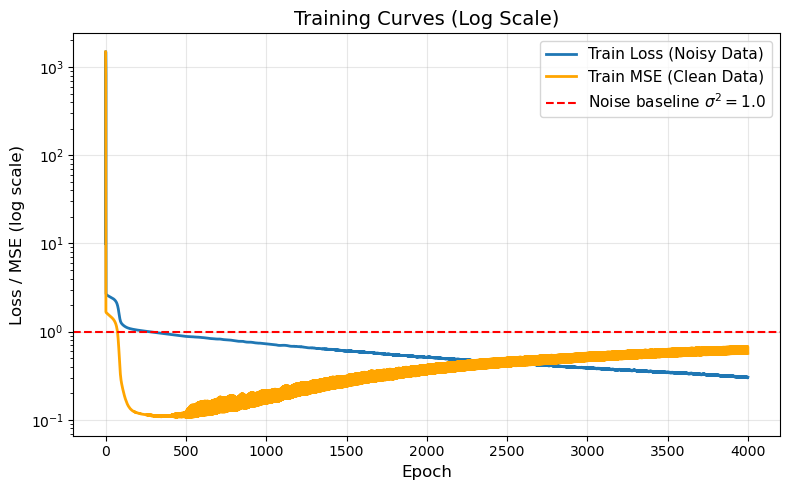


FINAL RESULTS
Final Train Loss: 0.304632
Final Train MSE:  0.570182
Noise baseline (σ²): 1.000000


In [22]:
# Run the augmented views experiment
result = run_augmented_views_experiment(
    m=9,              # Patch size
    L=10,             # Number of disjoint views (and periodic repetitions)
    R=20,             # Number of additional random views
    K=1024,           # Network width
    N=512,            # Number of samples
    sigma=1.0,        # Noise level
    K_ground_truth=50,
    lr=0.2,
    epochs=4000,
    print_every=200,
    random_seed=42
)

AUGMENTED LOCAL VIEWS EXPERIMENT
Input structure: Periodic identical patches
  - Patch size (m): 9
  - Repetitions (L): 10
  - Input dimension (d = L×m): 90

Local view structure: H = H_disjoint ∪ H_random
  - Disjoint consecutive views: 10
  - Random views: 60
  - Total views: 70

Network: width K=1024, ground truth K=50
Training: N=512 samples, σ=1.0, lr=0.2, epochs=4000

Generated 70 local views:
  - 10 disjoint consecutive blocks
  - 60 random views

✓ Dataset generated
✓ Total local views: 70
✓ Example disjoint views:
    H[0] = [0 1 2 3 4 5 6 7 8]
    H[1] = [ 9 10 11 12 13 14 15 16 17]
✓ Example random views:
    H[10] = [ 7 18 37 54 62 64 74 85 87]
    H[11] = [10 15 31 37 42 57 69 81 88]

✓ Model created: 11,265 parameters
✓ Device: cpu

Training...
Epoch    1/4000 | Train Loss (noisy): 9.877241 | Train MSE (clean): 1521.598511
Epoch  200/4000 | Train Loss (noisy): 1.100956 | Train MSE (clean): 0.099973
Epoch  400/4000 | Train Loss (noisy): 1.002081 | Train MSE (clean): 0.0533

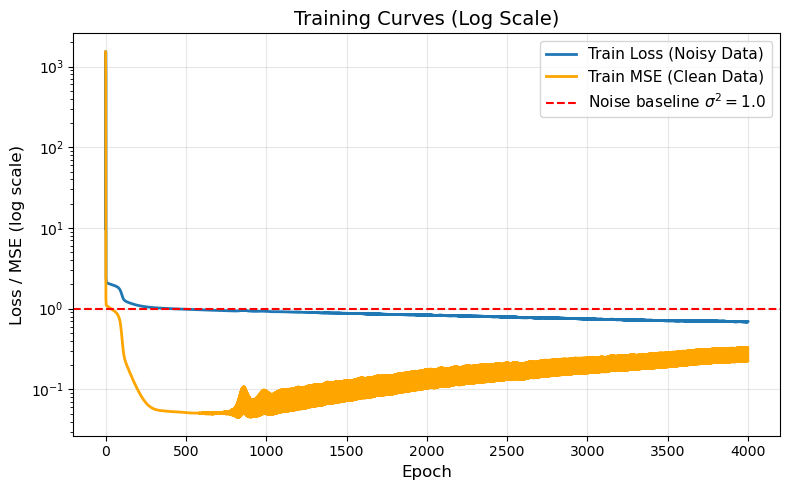


FINAL RESULTS
Final Train Loss: 0.690841
Final Train MSE:  0.225642
Noise baseline (σ²): 1.000000


In [24]:
# Run the augmented views experiment
result = run_augmented_views_experiment(
    m=9,              # Patch size
    L=10,             # Number of disjoint views (and periodic repetitions)
    R=60,             # Number of additional random views
    K=1024,           # Network width
    N=512,            # Number of samples
    sigma=1.0,        # Noise level
    K_ground_truth=50,
    lr=0.2,
    epochs=4000,
    print_every=200,
    random_seed=42
)

AUGMENTED LOCAL VIEWS EXPERIMENT
Input structure: Periodic identical patches
  - Patch size (m): 9
  - Repetitions (L): 10
  - Input dimension (d = L×m): 90

Local view structure: H = H_disjoint ∪ H_random
  - Disjoint consecutive views: 10
  - Random views: 80
  - Total views: 90

Network: width K=1024, ground truth K=50
Training: N=512 samples, σ=1.0, lr=0.2, epochs=4000

Generated 90 local views:
  - 10 disjoint consecutive blocks
  - 80 random views

✓ Dataset generated
✓ Total local views: 90
✓ Example disjoint views:
    H[0] = [0 1 2 3 4 5 6 7 8]
    H[1] = [ 9 10 11 12 13 14 15 16 17]
✓ Example random views:
    H[10] = [ 7 18 37 54 62 64 74 85 87]
    H[11] = [10 15 31 37 42 57 69 81 88]

✓ Model created: 11,265 parameters
✓ Device: cpu

Training...
Epoch    1/4000 | Train Loss (noisy): 9.497443 | Train MSE (clean): 1661.390503
Epoch  200/4000 | Train Loss (noisy): 1.090215 | Train MSE (clean): 0.091709
Epoch  400/4000 | Train Loss (noisy): 0.997587 | Train MSE (clean): 0.0405

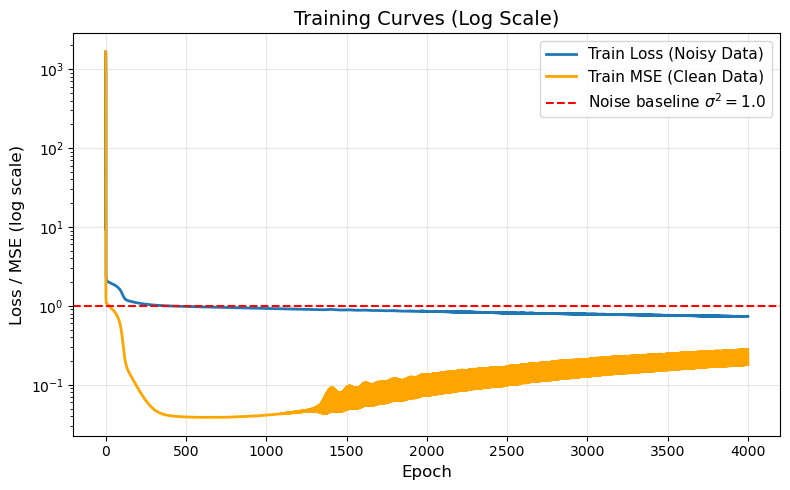


FINAL RESULTS
Final Train Loss: 0.735162
Final Train MSE:  0.180820
Noise baseline (σ²): 1.000000


In [25]:
# Run the augmented views experiment
result = run_augmented_views_experiment(
    m=9,              # Patch size
    L=10,             # Number of disjoint views (and periodic repetitions)
    R=80,             # Number of additional random views
    K=1024,           # Network width
    N=512,            # Number of samples
    sigma=1.0,        # Noise level
    K_ground_truth=50,
    lr=0.2,
    epochs=4000,
    print_every=200,
    random_seed=42
)